### Definición del valores máximos y mínimos para intervalo común de longitudes de onda

El objetivo de este código es definir un intervalo de longitudes de onda común para los espectros de la muestra de galaxias.

Para esto, se extraen de los espectros de las galaxias seleccionadas el máximo valor de entre todos los valores mínimos y el mínimo valor de todos los valores máximos, en longitud de onda.

Al final se muestra un distribución de todos los valores máximos y mínimos de loglam de cada espectro y los respectivos valores que definirán el intervalo de longitudes de onda común.


In [ ]:
import os
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
#path a la carpeta donde están los espectros (archivos fits)
dir = '/drive/My Drive/Data/raw_spec/'

In [ ]:
#crear lista de los espectros
fits_files = [os.path.join(dir, file) for file in os.listdir(dir)
    if file.startswith('spec') and file.endswith('.fits')]

In [ ]:
#crear las listas para guardar los máximos y mínimos de loglam
loglam_max = []
loglam_min = []

In [ ]:
#extraer valores máximos y mínimos loglam de cada espectro
for fits_file in fits_files:
    #print(f'Procesando archivo: {fits_file}')
    table = Table.read(fits_file, format='fits')

    #extraer los valores
    loglam_values = table['loglam']
    loglam_max.append(max(loglam_values))
    loglam_min.append(min(loglam_values))


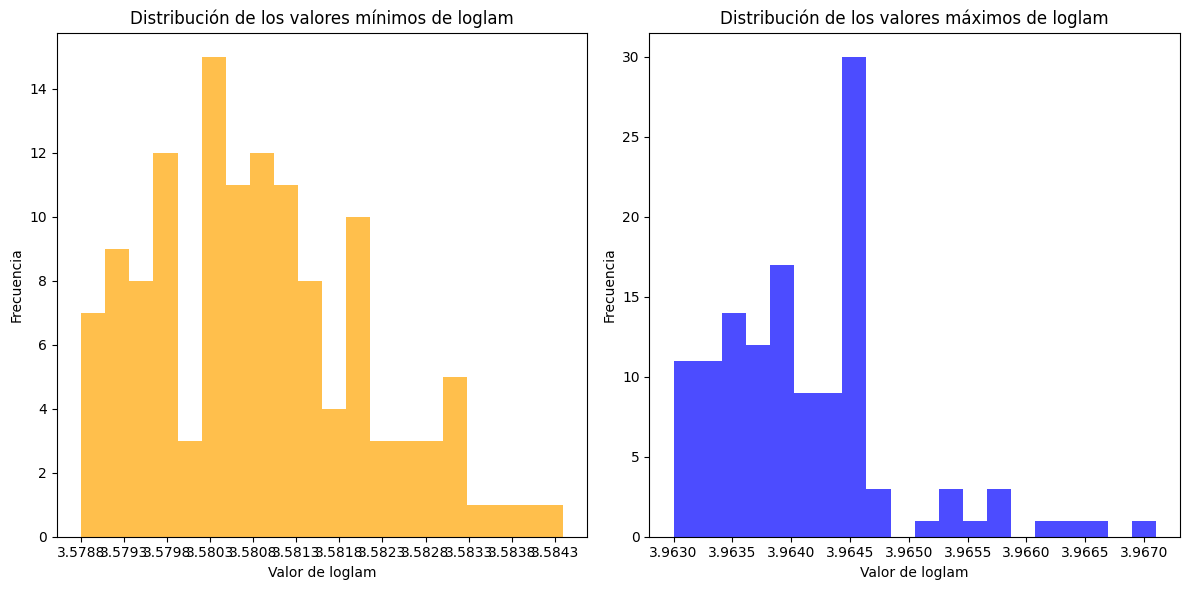

In [ ]:
#crear gráficos de las distribuciones de valores max y min
plt.figure(figsize=(12, 6))

#gráfico para los máximos
plt.subplot(1, 2, 2)
plt.hist(loglam_max, bins=20, color='blue', alpha=0.7)
plt.title('Distribución de los valores máximos de loglam')
plt.xlabel('Valor de loglam')
plt.ylabel('Frecuencia')

#establecer los saltos del eje X
min_x_max = min(loglam_max)
max_x_max = max(loglam_max)
plt.xticks(np.arange(min_x_max, max_x_max, 0.0005))


#gráfico para los mínimos
plt.subplot(1, 2, 1)
plt.hist(loglam_min, bins=20, color='orange', alpha=0.7)
plt.title('Distribución de los valores mínimos de loglam')
plt.xlabel('Valor de loglam')
plt.ylabel('Frecuencia')

#establecer los saltos del eje X
min_x_min = min(loglam_min)
max_x_min = max(loglam_min)
plt.xticks(np.arange(min_x_min, max_x_min, 0.0005))


# Mostrar los gráficos
plt.tight_layout()
plt.show()

In [ ]:
#al final se elegirá el valor mas grande los valores mínimos y el valor mas chico de los máximos para definir el rango de loglam

In [ ]:
print('Máximo valor de valores mínimos:', max(loglam_min), 'Mínimo valor de valores máximos:', min(loglam_max))

Máximo valor de valores mínimos: 3.5844 Mínimo valor de valores máximos: 3.963


In [ ]:
from statistics import mode #para mostrar el valor mas frecuente

In [ ]:
print(mode(loglam_max))

3.9645


In [ ]:
print(mode(loglam_min))

3.5803
